NAME - NIRJARA MORE

PRN - 202301100049

BATCH - A1

LAB ASSIGNMENT 1

Dataset - Iris species dataset

In [1]:
# ─────────────────────────────────────────────────────────────
# STEP 1 : Import Libraries
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print(f"Matplotlib ver : {matplotlib.__version__}")

Libraries imported successfully!
NumPy version  : 2.0.2
Pandas version : 2.2.2
Matplotlib ver : 3.10.0


Loading dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [4]:
import pandas as pd

df = pd.read_csv("Iris.csv")
print("First 5 rows of the dataset:")
print(df.head())

print("\nShape of dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

First 5 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Shape of dataset: (150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object



Basic Statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0

Number of duplicate rows: 0

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica 

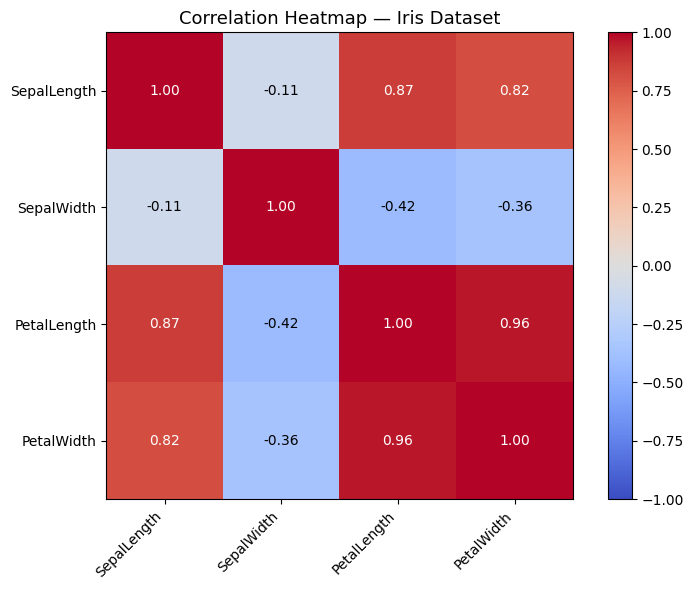

In [5]:
# ─────────────────────────────────────────────────────────────
# STEP 3 : Data Understanding & Exploration
# ─────────────────────────────────────────────────────────────

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nClass Distribution:")
print(df['Species'].value_counts())

# ── Correlation Heatmap ──────────────────────────────────────
df_corr = df.drop(columns=['Id', 'Species'])
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha='center', va='center', fontsize=10,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')

ax.set_title("Correlation Heatmap — Iris Dataset", fontsize=13)
plt.tight_layout()
plt.show()

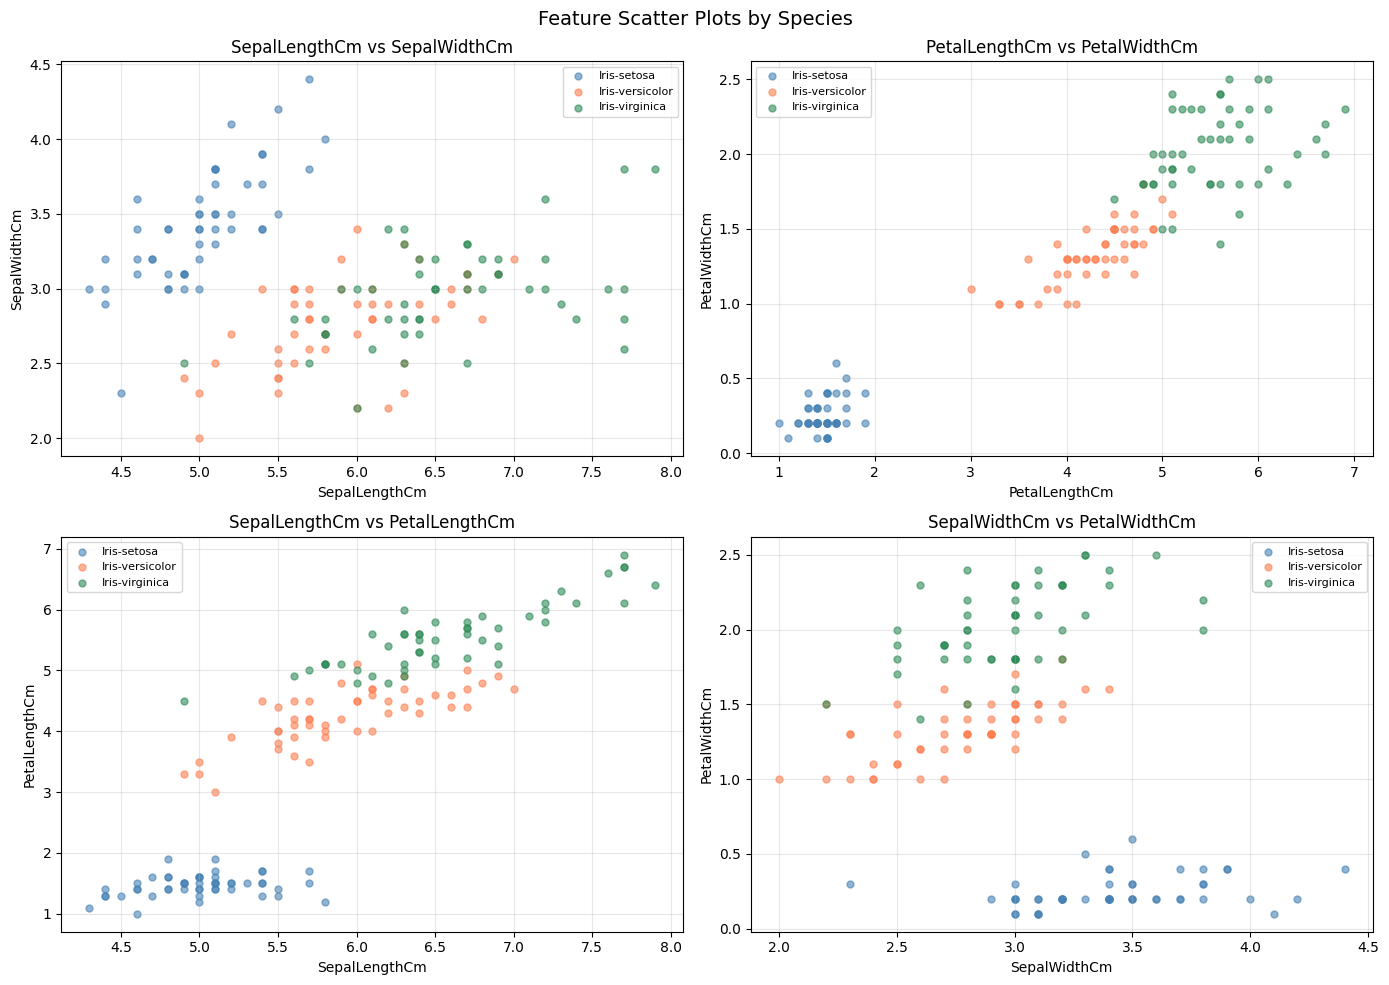

In [6]:
# ── Scatter Plots — Feature vs Feature coloured by Species ──
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
species_list = df['Species'].unique()
colors_sp    = ['steelblue', 'coral', 'seagreen']

pairs = [
    ('SepalLengthCm', 'SepalWidthCm'),
    ('PetalLengthCm', 'PetalWidthCm'),
    ('SepalLengthCm', 'PetalLengthCm'),
    ('SepalWidthCm',  'PetalWidthCm'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (fx, fy) in enumerate(pairs):
    for sp, c in zip(species_list, colors_sp):
        subset = df[df['Species'] == sp]
        axes[idx].scatter(subset[fx], subset[fy], label=sp, color=c, alpha=0.6, s=25)
    axes[idx].set_xlabel(fx); axes[idx].set_ylabel(fy)
    axes[idx].set_title(f'{fx} vs {fy}')
    axes[idx].legend(fontsize=8); axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Scatter Plots by Species', fontsize=14)
plt.tight_layout()
plt.show()

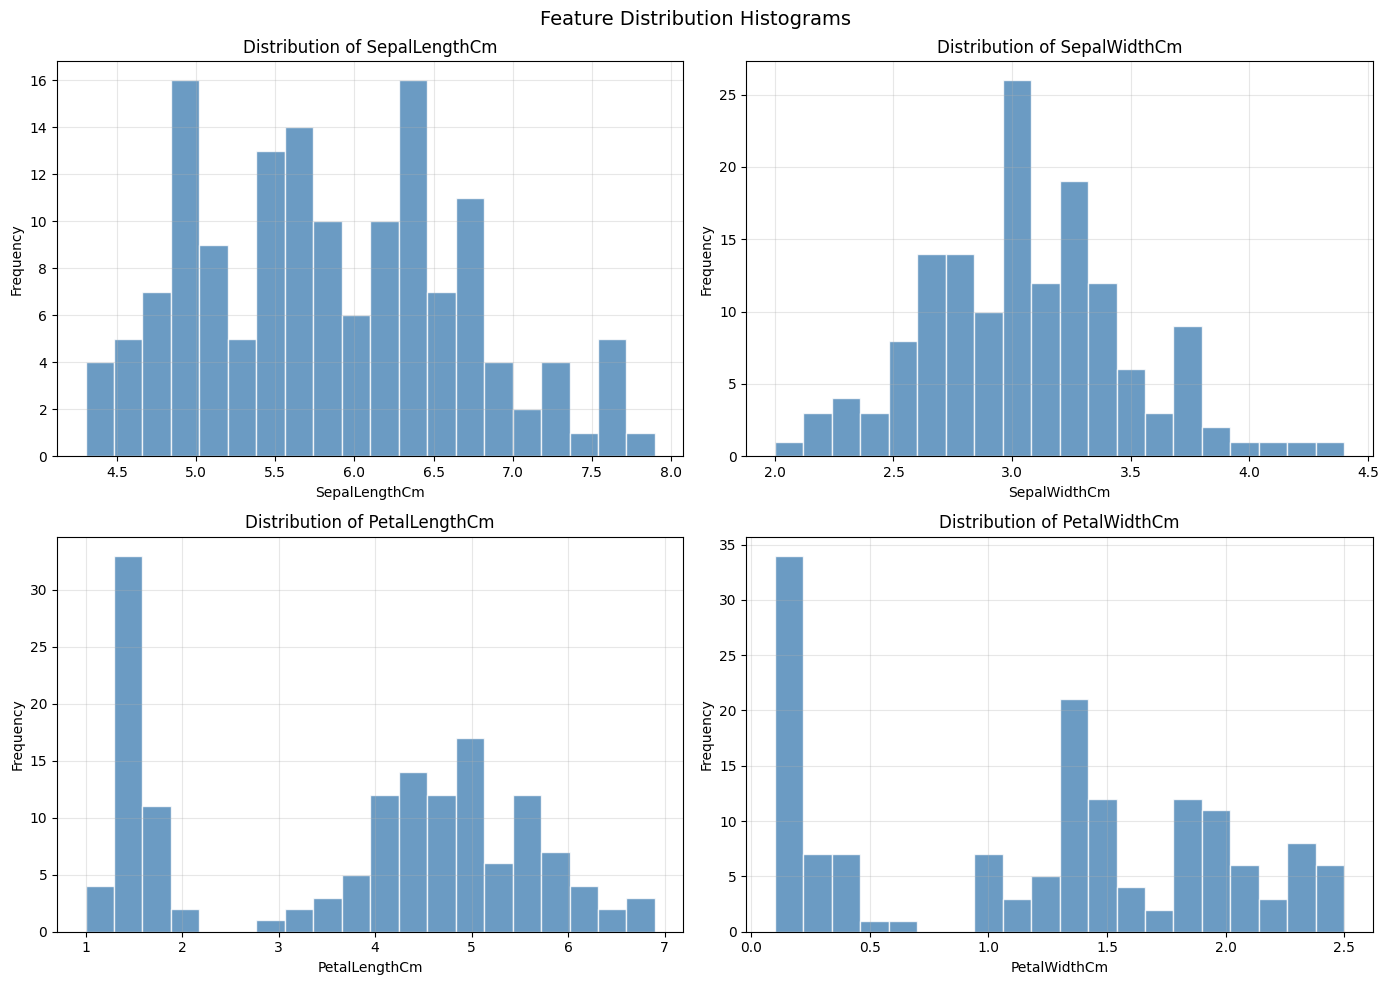

In [7]:
# ── Histograms — Feature Distributions ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distribution Histograms', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4050/714702885.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_per_species, patch_artist=True,
/tmp/ipykernel_4050/714702885.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_per_species, patch_artist=True,
/tmp/ipykernel_4050/714702885.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_per_species, patch_artist=True,
/tmp/ipykernel_4050/714702885.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


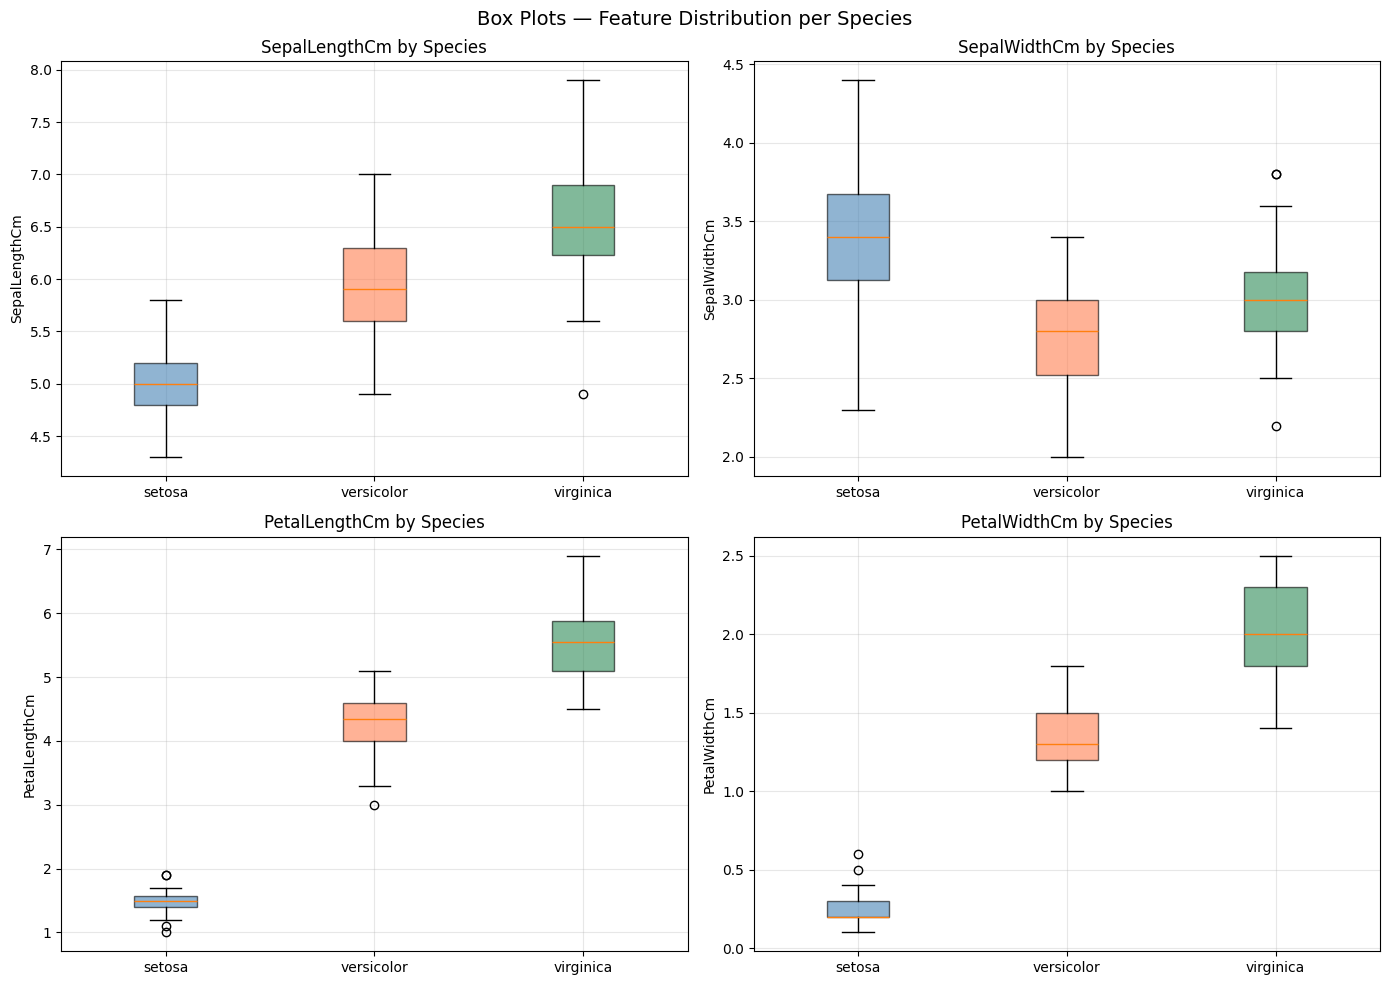

In [8]:
# ── Box Plots — Feature per Species ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data_per_species = [df[df['Species'] == sp][col].values for sp in species_list]
    bp = axes[i].boxplot(data_per_species, patch_artist=True,
                         labels=[s.replace('Iris-', '') for s in species_list])
    for patch, c in zip(bp['boxes'], colors_sp):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    axes[i].set_title(f'{col} by Species')
    axes[i].set_ylabel(col); axes[i].grid(True, alpha=0.3)

plt.suptitle('Box Plots — Feature Distribution per Species', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# ─────────────────────────────────────────────────────────────
# STEP 4 : Data Preprocessing
# ─────────────────────────────────────────────────────────────

# ── Drop Id column, rename features ─────────────────────────
df.columns = ['Id', 'SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']

print("Renamed columns:", df.columns.tolist())
print(df.head())

# ── Encode Labels (One-Hot Encoding) ─────────────────────────
# Iris-setosa     → [1, 0, 0]
# Iris-versicolor → [0, 1, 0]
# Iris-virginica  → [0, 0, 1]

class_names = sorted(df['Species'].unique())          # alphabetical order
class_to_idx = {name: i for i, name in enumerate(class_names)}
print("\nClass → Index mapping:", class_to_idx)

def one_hot_encode(labels, num_classes):
    m = len(labels)
    ohe = np.zeros((m, num_classes))
    for i, lbl in enumerate(labels):
        ohe[i, class_to_idx[lbl]] = 1
    return ohe

X = df[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']].values  # (150, 4)
y = one_hot_encode(df['Species'].values, num_classes=3)                      # (150, 3)

print("\nShape of X (features):", X.shape)
print("Shape of y (one-hot) :", y.shape)

Renamed columns: ['Id', 'SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']
   Id  SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0   1          5.1         3.5          1.4         0.2  Iris-setosa
1   2          4.9         3.0          1.4         0.2  Iris-setosa
2   3          4.7         3.2          1.3         0.2  Iris-setosa
3   4          4.6         3.1          1.5         0.2  Iris-setosa
4   5          5.0         3.6          1.4         0.2  Iris-setosa

Class → Index mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}

Shape of X (features): (150, 4)
Shape of y (one-hot) : (150, 3)


In [11]:
# ── Train-Test Split (80 / 20, manual) ──────────────────────
np.random.seed(42)
indices   = np.arange(X.shape[0])
np.random.shuffle(indices)

split_idx = int(0.8 * X.shape[0])
train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("\nX_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

# ── Z-score Standardization ──────────────────────────────────
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std

print("\nMean of scaled train features (should be ~0):")
print(X_train_scaled.mean(axis=0).round(4))
print("\nStd  of scaled train features (should be ~1):")
print(X_train_scaled.std(axis=0).round(4))



X_train shape: (120, 4)
X_test  shape: (30, 4)
y_train shape: (120, 3)
y_test  shape: (30, 3)

Mean of scaled train features (should be ~0):
[-0.  0. -0. -0.]

Std  of scaled train features (should be ~1):
[1. 1. 1. 1.]


In [12]:
# STEP 5 : Neural Network Architecture
#   Input Layer  : 4 neurons  (SepalLength, SepalWidth,
#                               PetalLength, PetalWidth)
#   Hidden Layer : 8 neurons  (configurable)
#   Output Layer : 3 neurons  (one per class)
#
#   Activation:
#     Hidden layer → Sigmoid
#     Output layer → Softmax  (multi-class classification)
#
#   Loss Function: Cross-Entropy

In [13]:
# ─────────────────────────────────────────────────────────────
# STEP 6 : Weight Initialization
# ─────────────────────────────────────────────────────────────

input_size  = X_train_scaled.shape[1]   # 4
hidden_size = 8                          # configurable
output_size = 3                          # 3 classes

def init_weights(input_size, hidden_size, output_size, seed=42):
    """
    Initialize weights with small random values.
    W1 : (input_size  × hidden_size)
    b1 : (1           × hidden_size)
    W2 : (hidden_size × output_size)
    b2 : (1           × output_size)
    """
    np.random.seed(seed)
    W1 = np.random.randn(input_size,  hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_weights(input_size, hidden_size, output_size)

print("Weight and Bias Shapes:")
print(f"  W1 : {W1.shape}  (input_size={input_size}  → hidden_size={hidden_size})")
print(f"  b1 : {b1.shape}")
print(f"  W2 : {W2.shape}  (hidden_size={hidden_size} → output_size={output_size})")
print(f"  b2 : {b2.shape}")

print("\nInitial W1 (first row):", W1[0])
print("Initial W2 (first col):", W2[:, 0])



Weight and Bias Shapes:
  W1 : (4, 8)  (input_size=4  → hidden_size=8)
  b1 : (1, 8)
  W2 : (8, 3)  (hidden_size=8 → output_size=3)
  b2 : (1, 3)

Initial W1 (first row): [ 0.04967142 -0.01382643  0.06476885  0.15230299 -0.02341534 -0.0234137
  0.15792128  0.07674347]
Initial W2 (first col): [-0.00134972 -0.12208436 -0.1328186   0.01713683 -0.1478522   0.10571222
  0.0324084   0.06116763]


In [14]:
# ─────────────────────────────────────────────────────────────
# STEP 7 : Activation Functions
# ─────────────────────────────────────────────────────────────

def sigmoid(x):
    """Sigmoid: squashes values to (0, 1)."""
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(A):
    """Derivative of sigmoid given output A = sigmoid(x)."""
    return A * (1.0 - A)

def softmax(Z):
    """
    Softmax activation for output layer (multi-class).
    Numerically stable version (subtract row max before exp).
    """
    Z_shifted = Z - Z.max(axis=1, keepdims=True)
    exp_Z     = np.exp(Z_shifted)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

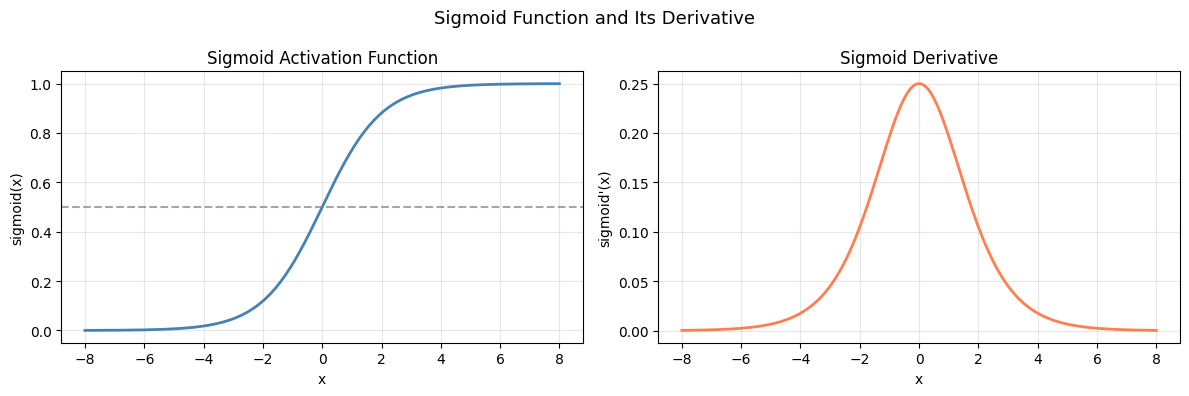

sigmoid(0)   = 0.5
sigmoid(10)  = 0.999955
sigmoid(-10) = 4.5e-05


In [15]:
# ── Visualize Sigmoid ────────────────────────────────────────
x_vals  = np.linspace(-8, 8, 200)
y_vals  = sigmoid(x_vals)
dy_vals = sigmoid_derivative(y_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_vals, y_vals,  color='steelblue', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('Sigmoid Activation Function')
axes[0].set_xlabel('x'); axes[0].set_ylabel('sigmoid(x)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, dy_vals, color='coral', linewidth=2)
axes[1].set_title('Sigmoid Derivative')
axes[1].set_xlabel('x'); axes[1].set_ylabel("sigmoid'(x)")
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sigmoid Function and Its Derivative', fontsize=13)
plt.tight_layout(); plt.show()

print("sigmoid(0)   =", sigmoid(0))
print("sigmoid(10)  =", round(sigmoid(10), 6))
print("sigmoid(-10) =", round(sigmoid(-10), 6))

In [16]:
# ── Visualize Softmax (sample input) ─────────────────────────
z_sample   = np.array([[2.0, 1.0, 0.5]])
sm_out     = softmax(z_sample)
print("\nSoftmax demo:")
print("  Input : ", z_sample[0])
print("  Output:", sm_out[0].round(4))
print("  Sum   :", sm_out[0].sum().round(6))


Softmax demo:
  Input :  [2.  1.  0.5]
  Output: [0.6285 0.2312 0.1402]
  Sum   : 1.0


In [17]:
# ─────────────────────────────────────────────────────────────
# STEP 8 : Forward Propagation
# ─────────────────────────────────────────────────────────────
#
#   Hidden layer:
#     Z1     = X · W1 + b1
#     A1     = sigmoid(Z1)
#   Output layer:
#     Z2     = A1 · W2 + b2
#     y_pred = softmax(Z2)      ← probabilities over 3 classes

def forward_propagation(X, W1, b1, W2, b2):
    Z1     = np.dot(X, W1) + b1       # (m, hidden_size)
    A1     = sigmoid(Z1)               # (m, hidden_size)
    Z2     = np.dot(A1, W2) + b2       # (m, output_size)
    y_pred = softmax(Z2)               # (m, 3)
    return Z1, A1, Z2, y_pred

# ── Test forward pass ────────────────────────────────────────
Z1, A1, Z2, y_pred = forward_propagation(X_train_scaled, W1, b1, W2, b2)

print("Forward Propagation — Shape Check:")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  Z1             : {Z1.shape}")
print(f"  A1             : {A1.shape}")
print(f"  Z2             : {Z2.shape}")
print(f"  y_pred         : {y_pred.shape}")
print(f"\nFirst 5 predicted probabilities:")
print(y_pred[:5].round(4))
print(f"\nFirst 5 actual labels (one-hot):")
print(y_train[:5])

Forward Propagation — Shape Check:
  X_train_scaled : (120, 4)
  Z1             : (120, 8)
  A1             : (120, 8)
  Z2             : (120, 3)
  y_pred         : (120, 3)

First 5 predicted probabilities:
[[0.3313 0.3534 0.3153]
 [0.3254 0.3524 0.3222]
 [0.3333 0.3537 0.3131]
 [0.3309 0.3536 0.3155]
 [0.3316 0.353  0.3154]]

First 5 actual labels (one-hot):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [18]:
# ─────────────────────────────────────────────────────────────
# STEP 9 : Loss Function (Cross-Entropy)
# ─────────────────────────────────────────────────────────────
#   Loss = -(1/m) * Σ Σ y_true * log(y_pred)
#   Clip predictions to avoid log(0)

def compute_cross_entropy(y_true, y_pred):
    m       = y_true.shape[0]
    y_clip  = np.clip(y_pred, 1e-12, 1 - 1e-12)
    return -np.sum(y_true * np.log(y_clip)) / m

initial_loss = compute_cross_entropy(y_train, y_pred)
print(f"Initial Cross-Entropy Loss (before training): {initial_loss:.4f}")


Initial Cross-Entropy Loss (before training): 1.1041


In [19]:
# ─────────────────────────────────────────────────────────────
# STEP 10 : Backpropagation
# ─────────────────────────────────────────────────────────────
#
#   Output layer:
#     dZ2 = (y_pred - y_true) / m          ← softmax + CE combined gradient
#     dW2 = A1.T · dZ2
#     db2 = sum(dZ2, axis=0)
#
#   Hidden layer:
#     dA1 = dZ2 · W2.T
#     dZ1 = dA1 * sigmoid_deriv(A1)
#     dW1 = X.T · dZ1
#     db1 = sum(dZ1, axis=0)

def backpropagation(X, y_true, y_pred, A1, W2):
    m   = y_true.shape[0]
    dZ2 = (y_pred - y_true) / m                    # (m, 3)
    dW2 = np.dot(A1.T, dZ2)                         # (hidden, 3)
    db2 = np.sum(dZ2, axis=0, keepdims=True)         # (1, 3)

    dA1 = np.dot(dZ2, W2.T)                          # (m, hidden)
    dZ1 = dA1 * sigmoid_derivative(A1)               # (m, hidden)
    dW1 = np.dot(X.T, dZ1)                           # (4, hidden)
    db1 = np.sum(dZ1, axis=0, keepdims=True)          # (1, hidden)
    return dW1, db1, dW2, db2

dW1, db1_g, dW2, db2_g = backpropagation(X_train_scaled, y_train, y_pred, A1, W2)

print("Backpropagation — Gradient Shape Check:")
print(f"  dW2 : {dW2.shape}")
print(f"  db2 : {db2_g.shape}")
print(f"  dW1 : {dW1.shape}")
print(f"  db1 : {db1_g.shape}")


Backpropagation — Gradient Shape Check:
  dW2 : (8, 3)
  db2 : (1, 3)
  dW1 : (4, 8)
  db1 : (1, 8)


In [20]:
# ─────────────────────────────────────────────────────────────
# STEP 11 : Gradient Descent (Weight Update)
# ─────────────────────────────────────────────────────────────

def update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    """W = W - lr * gradient"""
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

print("Weight update function defined.")
print("Formula: W_new = W_old - learning_rate * gradient")


Weight update function defined.
Formula: W_new = W_old - learning_rate * gradient


In [21]:
# ─────────────────────────────────────────────────────────────
# STEP 12 : Training — Batch Gradient Descent (Baseline)
# ─────────────────────────────────────────────────────────────

def train_batch_gd(X, y, input_size, hidden_size, output_size,
                   lr=0.1, epochs=1000, print_every=100, seed=42):
    W1, b1, W2, b2 = init_weights(input_size, hidden_size, output_size, seed)
    loss_history    = []

    for epoch in range(epochs):
        _, A1, _, y_pred = forward_propagation(X, W1, b1, W2, b2)
        loss = compute_cross_entropy(y, y_pred)
        loss_history.append(loss)
        dW1, db1, dW2, db2 = backpropagation(X, y, y_pred, A1, W2)
        W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

        if epoch % print_every == 0:
            print(f"  Epoch {epoch:5d} | Loss: {loss:.4f}")

    return W1, b1, W2, b2, loss_history

print("Training with Batch GD (lr=0.1, 1000 epochs)...")
W1_trained, b1_trained, W2_trained, b2_trained, loss_hist = train_batch_gd(
    X_train_scaled, y_train,
    input_size, hidden_size, output_size,
    lr=0.1, epochs=1000, print_every=100
)
print(f"\nFinal Training Loss: {loss_hist[-1]:.4f}")


Training with Batch GD (lr=0.1, 1000 epochs)...
  Epoch     0 | Loss: 1.1041
  Epoch   100 | Loss: 0.9017
  Epoch   200 | Loss: 0.5296
  Epoch   300 | Loss: 0.4106
  Epoch   400 | Loss: 0.3452
  Epoch   500 | Loss: 0.2983
  Epoch   600 | Loss: 0.2622
  Epoch   700 | Loss: 0.2332
  Epoch   800 | Loss: 0.2092
  Epoch   900 | Loss: 0.1890

Final Training Loss: 0.1722


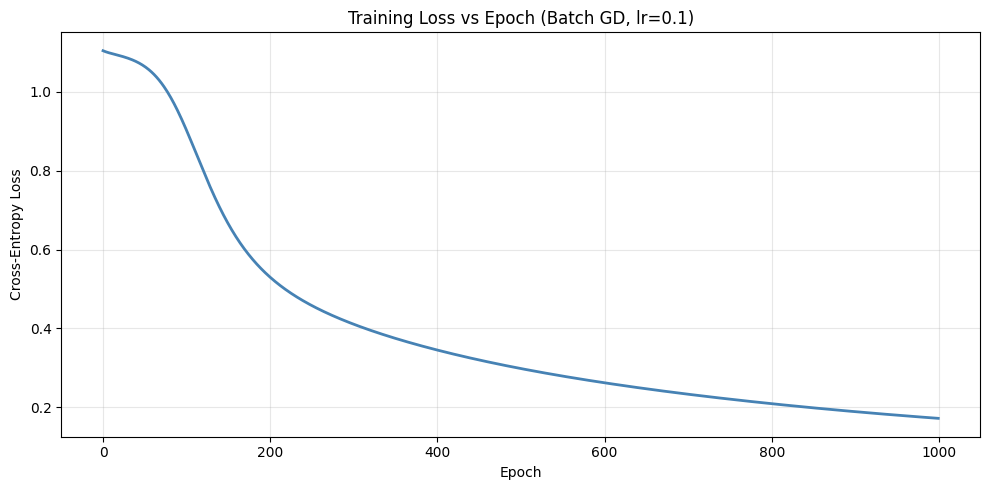

Starting Loss : 1.1041
Final Loss    : 0.1722
Improvement   : 0.9319


In [22]:
# ─────────────────────────────────────────────────────────────
# STEP 13 : Loss vs Epoch Visualization
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(loss_hist, color='steelblue', linewidth=2)
plt.title('Training Loss vs Epoch (Batch GD, lr=0.1)')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Starting Loss : {loss_hist[0]:.4f}")
print(f"Final Loss    : {loss_hist[-1]:.4f}")
print(f"Improvement   : {loss_hist[0] - loss_hist[-1]:.4f}")

Learning Rate Experiment:

Training with lr=0.001...
  Epoch     0 | Loss: 1.1041
  Epoch   500 | Loss: 1.1002
  Final Loss: 1.0971

Training with lr=0.01...
  Epoch     0 | Loss: 1.1041
  Epoch   500 | Loss: 1.0631
  Final Loss: 0.8982

Training with lr=0.1...
  Epoch     0 | Loss: 1.1041
  Epoch   500 | Loss: 0.2983
  Final Loss: 0.1722


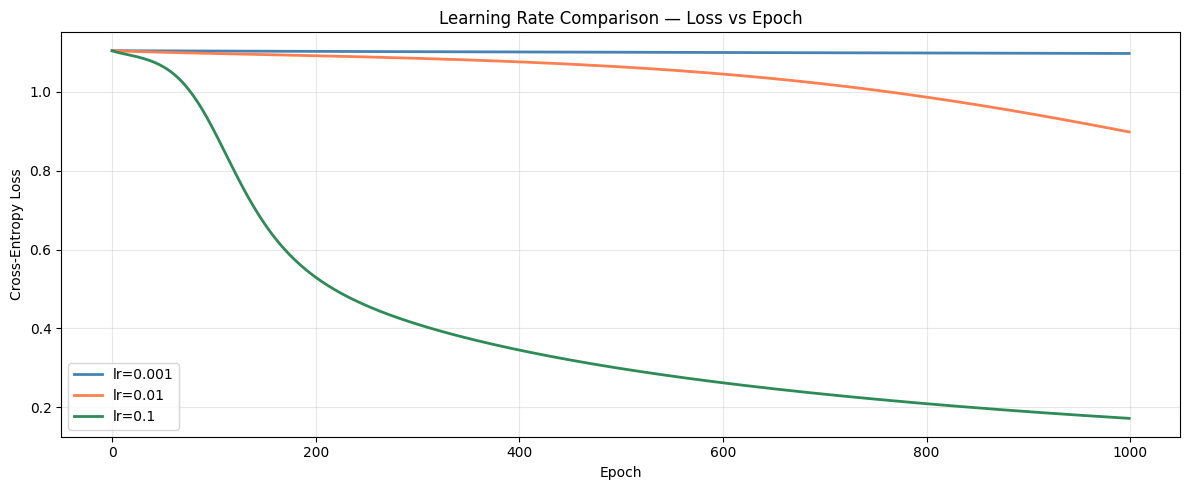


Summary:
  lr=0.001  → Final Loss: 1.0971
  lr=0.01   → Final Loss: 0.8982
  lr=0.1    → Final Loss: 0.1722

Hidden Layer Size Experiment:

Training with hidden_size=2...
  Epoch     0 | Loss: 1.1010
  Epoch   500 | Loss: 0.4461
  Final Loss: 0.3172

Training with hidden_size=4...
  Epoch     0 | Loss: 1.0986
  Epoch   500 | Loss: 0.4020
  Final Loss: 0.2407

Training with hidden_size=8...
  Epoch     0 | Loss: 1.1041
  Epoch   500 | Loss: 0.2983
  Final Loss: 0.1722

Training with hidden_size=16...
  Epoch     0 | Loss: 1.1009
  Epoch   500 | Loss: 0.2447
  Final Loss: 0.1417


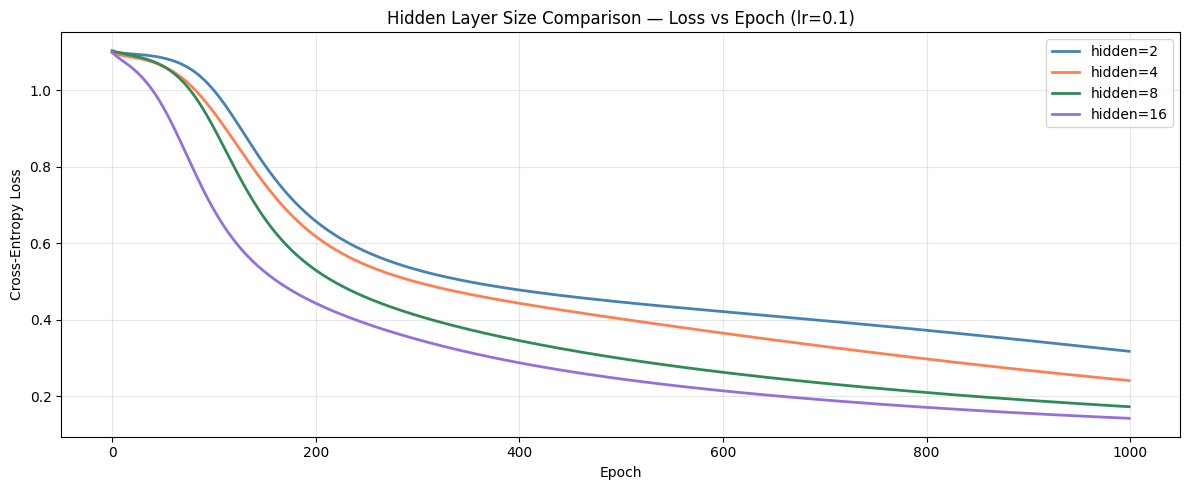


Summary:
  hidden_size=2   → Final Loss: 0.3172
  hidden_size=4   → Final Loss: 0.2407
  hidden_size=8   → Final Loss: 0.1722
  hidden_size=16  → Final Loss: 0.1417


In [23]:
# ─────────────────────────────────────────────────────────────
# STEP 14 : Experiments
# ─────────────────────────────────────────────────────────────

# ── Experiment A : Learning Rate Comparison ──────────────────
learning_rates = [0.001, 0.01, 0.1]
lr_losses = {}

print("Learning Rate Experiment:")
print("=" * 50)
for lr in learning_rates:
    print(f"\nTraining with lr={lr}...")
    _, _, _, _, lh = train_batch_gd(
        X_train_scaled, y_train,
        input_size, hidden_size, output_size,
        lr=lr, epochs=1000, print_every=500
    )
    lr_losses[lr] = lh
    print(f"  Final Loss: {lh[-1]:.4f}")

plt.figure(figsize=(12, 5))
colors = ['steelblue', 'coral', 'seagreen']
for (lr, lh), c in zip(lr_losses.items(), colors):
    plt.plot(lh, label=f'lr={lr}', color=c, linewidth=2)
plt.title('Learning Rate Comparison — Loss vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\nSummary:")
for lr, lh in lr_losses.items():
    print(f"  lr={lr:<6} → Final Loss: {lh[-1]:.4f}")

# ── Experiment B : Hidden Layer Size Comparison ──────────────
hidden_sizes = [2, 4, 8, 16]
hs_losses = {}

print("\nHidden Layer Size Experiment:")
print("=" * 50)
for hs in hidden_sizes:
    print(f"\nTraining with hidden_size={hs}...")
    _, _, _, _, lh = train_batch_gd(
        X_train_scaled, y_train,
        input_size, hs, output_size,
        lr=0.1, epochs=1000, print_every=500
    )
    hs_losses[hs] = lh
    print(f"  Final Loss: {lh[-1]:.4f}")

plt.figure(figsize=(12, 5))
palette4 = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
for (hs, lh), c in zip(hs_losses.items(), palette4):
    plt.plot(lh, label=f'hidden={hs}', color=c, linewidth=2)
plt.title('Hidden Layer Size Comparison — Loss vs Epoch (lr=0.1)')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\nSummary:")
for hs, lh in hs_losses.items():
    print(f"  hidden_size={hs:<3} → Final Loss: {lh[-1]:.4f}")


Training Batch GD...
Training SGD...
Training Mini-Batch GD...


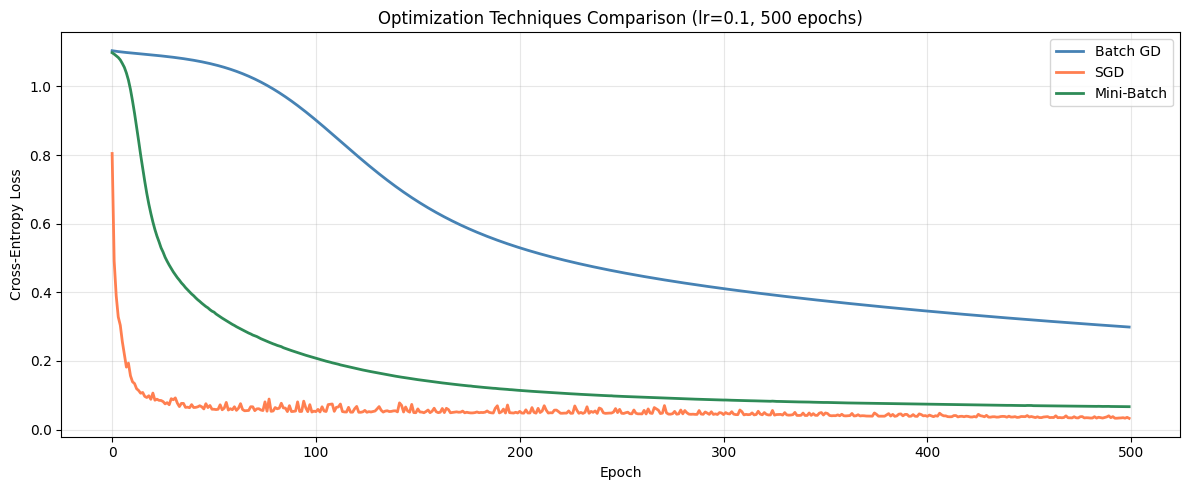


Final Losses:
  Batch GD   : 0.2987
  SGD        : 0.0325
  Mini-Batch : 0.0665


In [24]:
# ─────────────────────────────────────────────────────────────
# STEP 15 : Optimization Techniques
# ─────────────────────────────────────────────────────────────

# ── 15A : Batch Gradient Descent ─────────────────────────────
def train_batch(X, y, hidden_size=8, lr=0.1, epochs=500, seed=42):
    n_in = X.shape[1]; n_out = y.shape[1]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, n_out, seed)
    loss_hist = []
    for _ in range(epochs):
        _, A1, _, y_pred = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_cross_entropy(y, y_pred))
        dW1, db1, dW2, db2 = backpropagation(X, y, y_pred, A1, W2)
        W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)
    return W1, b1, W2, b2, loss_hist

# ── 15B : Stochastic Gradient Descent (SGD) ──────────────────
def train_sgd(X, y, hidden_size=8, lr=0.1, epochs=500, seed=42):
    n_in = X.shape[1]; n_out = y.shape[1]; m = X.shape[0]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, n_out, seed)
    loss_hist = []
    for _ in range(epochs):
        idx = np.random.permutation(m)
        for i in idx:
            Xi, yi = X[i:i+1], y[i:i+1]
            _, A1, _, yp = forward_propagation(Xi, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backpropagation(Xi, yi, yp, A1, W2)
            W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)
        _, _, _, yf = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_cross_entropy(y, yf))
    return W1, b1, W2, b2, loss_hist

# ── 15C : Mini-Batch Gradient Descent ────────────────────────
def train_minibatch(X, y, hidden_size=8, lr=0.1, epochs=500,
                    batch_size=16, seed=42):
    n_in = X.shape[1]; n_out = y.shape[1]; m = X.shape[0]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, n_out, seed)
    loss_hist = []
    for _ in range(epochs):
        idx = np.random.permutation(m)
        Xs, ys = X[idx], y[idx]
        for start in range(0, m, batch_size):
            Xb, yb = Xs[start:start+batch_size], ys[start:start+batch_size]
            _, A1, _, yp = forward_propagation(Xb, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backpropagation(Xb, yb, yp, A1, W2)
            W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)
        _, _, _, yf = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_cross_entropy(y, yf))
    return W1, b1, W2, b2, loss_hist

EPOCHS = 500; LR = 0.1

print("Training Batch GD...")
_, _, _, _, loss_batch = train_batch(X_train_scaled, y_train, lr=LR, epochs=EPOCHS)

print("Training SGD...")
_, _, _, _, loss_sgd = train_sgd(X_train_scaled, y_train, lr=LR, epochs=EPOCHS)

print("Training Mini-Batch GD...")
_, _, _, _, loss_mb = train_minibatch(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_size=16)

plt.figure(figsize=(12, 5))
plt.plot(loss_batch, label='Batch GD',   color='steelblue', linewidth=2)
plt.plot(loss_sgd,   label='SGD',        color='coral',     linewidth=2)
plt.plot(loss_mb,    label='Mini-Batch', color='seagreen',  linewidth=2)
plt.title('Optimization Techniques Comparison (lr=0.1, 500 epochs)')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\nFinal Losses:")
print(f"  Batch GD   : {loss_batch[-1]:.4f}")
print(f"  SGD        : {loss_sgd[-1]:.4f}")
print(f"  Mini-Batch : {loss_mb[-1]:.4f}")

Training with Momentum optimizer...


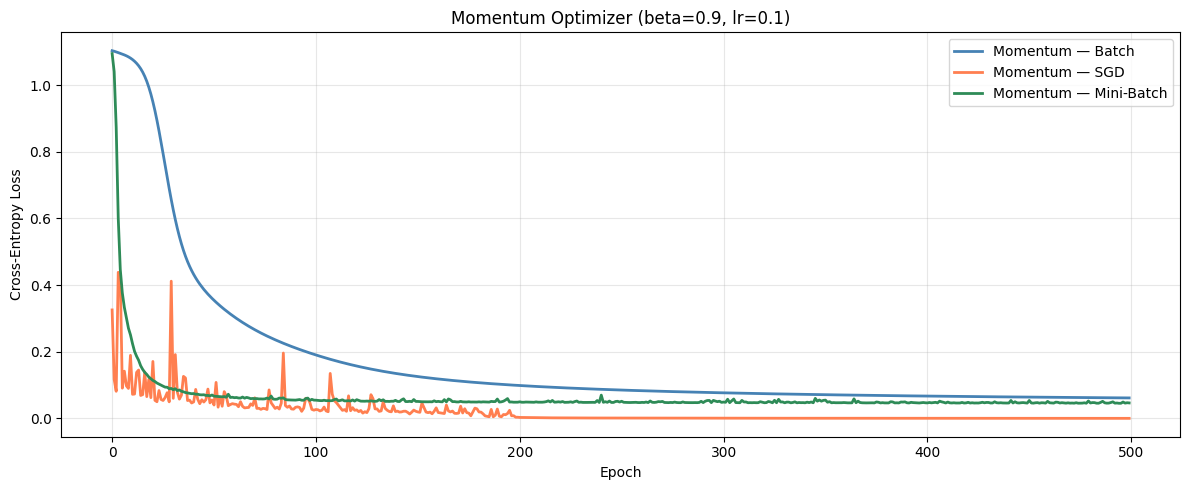

Momentum Final Losses:
  Batch     : 0.0616
  SGD       : 0.0003
  Mini-Batch: 0.0466

Training with Nesterov optimizer...


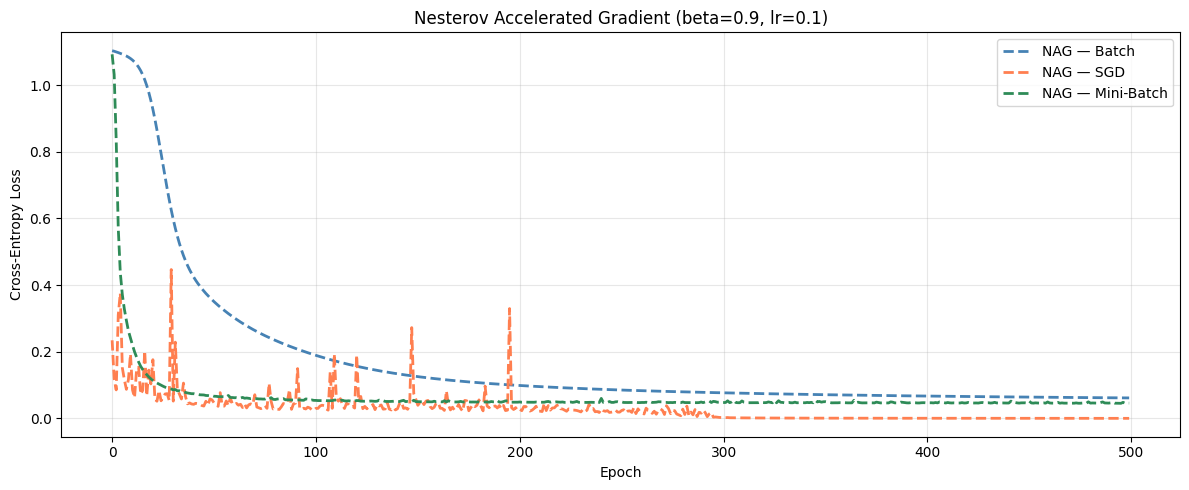

Nesterov Final Losses:
  Batch     : 0.0616
  SGD       : 0.0004
  Mini-Batch: 0.0460


In [25]:
# ─────────────────────────────────────────────────────────────
# STEP 16 : Advanced Optimizers — Momentum & Nesterov
# ─────────────────────────────────────────────────────────────

# ── Momentum ─────────────────────────────────────────────────
def train_momentum(X, y, hidden_size=8, lr=0.1, epochs=500,
                   beta=0.9, batch_type='batch', batch_size=16, seed=42):
    n_in = X.shape[1]; n_out = y.shape[1]; m = X.shape[0]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, n_out, seed)
    vW1 = np.zeros_like(W1); vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2); vb2 = np.zeros_like(b2)
    loss_hist = []

    def mom_update(W1, b1, W2, b2, dW1, db1, dW2, db2):
        nonlocal vW1, vb1, vW2, vb2
        vW1 = beta*vW1 - lr*dW1; vb1 = beta*vb1 - lr*db1
        vW2 = beta*vW2 - lr*dW2; vb2 = beta*vb2 - lr*db2
        return W1+vW1, b1+vb1, W2+vW2, b2+vb2

    for _ in range(epochs):
        if batch_type == 'batch':
            _, A1, _, yp = forward_propagation(X, W1, b1, W2, b2)
            dW1g, db1g, dW2g, db2g = backpropagation(X, y, yp, A1, W2)
            W1, b1, W2, b2 = mom_update(W1, b1, W2, b2, dW1g, db1g, dW2g, db2g)
        elif batch_type == 'sgd':
            for i in np.random.permutation(m):
                _, A1, _, yp = forward_propagation(X[i:i+1], W1, b1, W2, b2)
                dW1g, db1g, dW2g, db2g = backpropagation(X[i:i+1], y[i:i+1], yp, A1, W2)
                W1, b1, W2, b2 = mom_update(W1, b1, W2, b2, dW1g, db1g, dW2g, db2g)
        else:
            idx = np.random.permutation(m)
            for s in range(0, m, batch_size):
                Xb, yb = X[idx[s:s+batch_size]], y[idx[s:s+batch_size]]
                _, A1, _, yp = forward_propagation(Xb, W1, b1, W2, b2)
                dW1g, db1g, dW2g, db2g = backpropagation(Xb, yb, yp, A1, W2)
                W1, b1, W2, b2 = mom_update(W1, b1, W2, b2, dW1g, db1g, dW2g, db2g)
        _, _, _, yf = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_cross_entropy(y, yf))
    return W1, b1, W2, b2, loss_hist

# ── Nesterov Accelerated Gradient ────────────────────────────
def train_nesterov(X, y, hidden_size=8, lr=0.1, epochs=500,
                   beta=0.9, batch_type='batch', batch_size=16, seed=42):
    n_in = X.shape[1]; n_out = y.shape[1]; m = X.shape[0]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, n_out, seed)
    vW1 = np.zeros_like(W1); vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2); vb2 = np.zeros_like(b2)
    loss_hist = []

    def nag_step(Xi, yi, W1, b1, W2, b2):
        nonlocal vW1, vb1, vW2, vb2
        W1l, b1l = W1+beta*vW1, b1+beta*vb1
        W2l, b2l = W2+beta*vW2, b2+beta*vb2
        _, A1l, _, ypl = forward_propagation(Xi, W1l, b1l, W2l, b2l)
        dW1g, db1g, dW2g, db2g = backpropagation(Xi, yi, ypl, A1l, W2l)
        vW1 = beta*vW1 - lr*dW1g; vb1 = beta*vb1 - lr*db1g
        vW2 = beta*vW2 - lr*dW2g; vb2 = beta*vb2 - lr*db2g
        return W1+vW1, b1+vb1, W2+vW2, b2+vb2

    for _ in range(epochs):
        if batch_type == 'batch':
            W1, b1, W2, b2 = nag_step(X, y, W1, b1, W2, b2)
        elif batch_type == 'sgd':
            for i in np.random.permutation(m):
                W1, b1, W2, b2 = nag_step(X[i:i+1], y[i:i+1], W1, b1, W2, b2)
        else:
            idx = np.random.permutation(m)
            for s in range(0, m, batch_size):
                W1, b1, W2, b2 = nag_step(X[idx[s:s+batch_size]], y[idx[s:s+batch_size]], W1, b1, W2, b2)
        _, _, _, yf = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_cross_entropy(y, yf))
    return W1, b1, W2, b2, loss_hist

print("Training with Momentum optimizer...")
_, _, _, _, loss_mom_batch = train_momentum(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_type='batch')
_, _, _, _, loss_mom_sgd   = train_momentum(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_type='sgd')
_, _, _, _, loss_mom_mb    = train_momentum(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_type='minibatch')

plt.figure(figsize=(12, 5))
plt.plot(loss_mom_batch, label='Momentum — Batch',      color='steelblue', linewidth=2)
plt.plot(loss_mom_sgd,   label='Momentum — SGD',        color='coral',     linewidth=2)
plt.plot(loss_mom_mb,    label='Momentum — Mini-Batch', color='seagreen',  linewidth=2)
plt.title('Momentum Optimizer (beta=0.9, lr=0.1)')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Momentum Final Losses:")
print(f"  Batch     : {loss_mom_batch[-1]:.4f}")
print(f"  SGD       : {loss_mom_sgd[-1]:.4f}")
print(f"  Mini-Batch: {loss_mom_mb[-1]:.4f}")

print("\nTraining with Nesterov optimizer...")
_, _, _, _, loss_nag_batch = train_nesterov(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_type='batch')
_, _, _, _, loss_nag_sgd   = train_nesterov(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_type='sgd')
_, _, _, _, loss_nag_mb    = train_nesterov(X_train_scaled, y_train, lr=LR, epochs=EPOCHS, batch_type='minibatch')

plt.figure(figsize=(12, 5))
plt.plot(loss_nag_batch, label='NAG — Batch',      color='steelblue', linestyle='--', linewidth=2)
plt.plot(loss_nag_sgd,   label='NAG — SGD',        color='coral',     linestyle='--', linewidth=2)
plt.plot(loss_nag_mb,    label='NAG — Mini-Batch', color='seagreen',  linestyle='--', linewidth=2)
plt.title('Nesterov Accelerated Gradient (beta=0.9, lr=0.1)')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Nesterov Final Losses:")
print(f"  Batch     : {loss_nag_batch[-1]:.4f}")
print(f"  SGD       : {loss_nag_sgd[-1]:.4f}")
print(f"  Mini-Batch: {loss_nag_mb[-1]:.4f}")


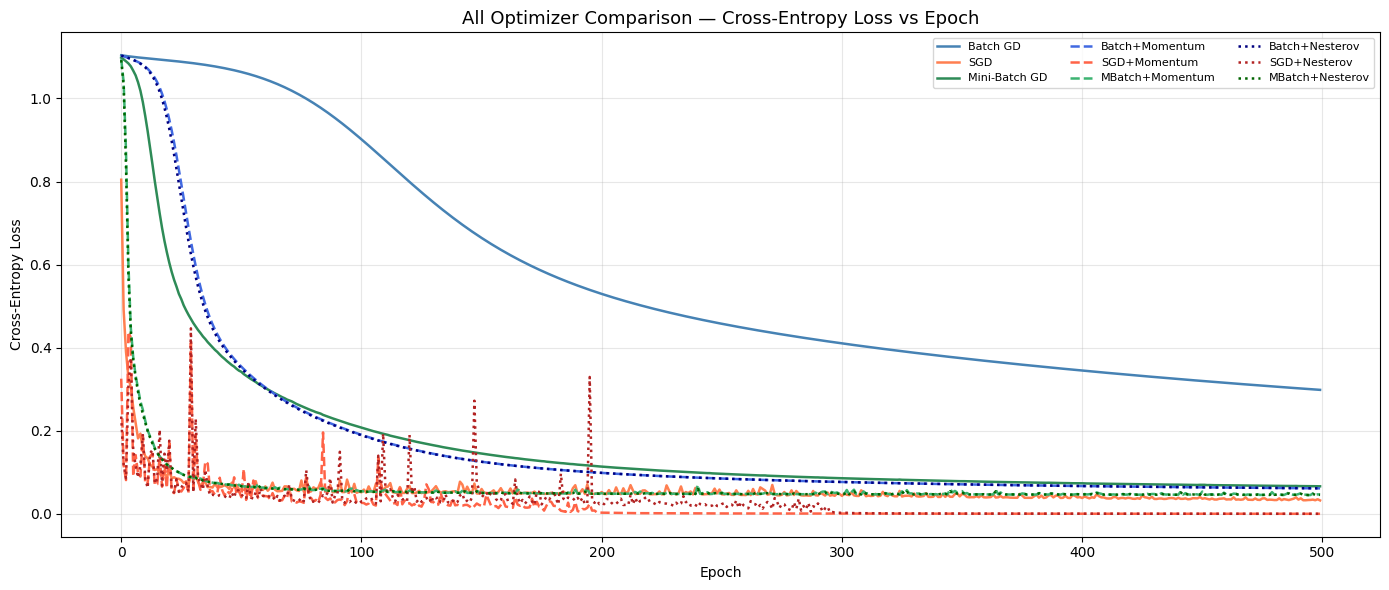

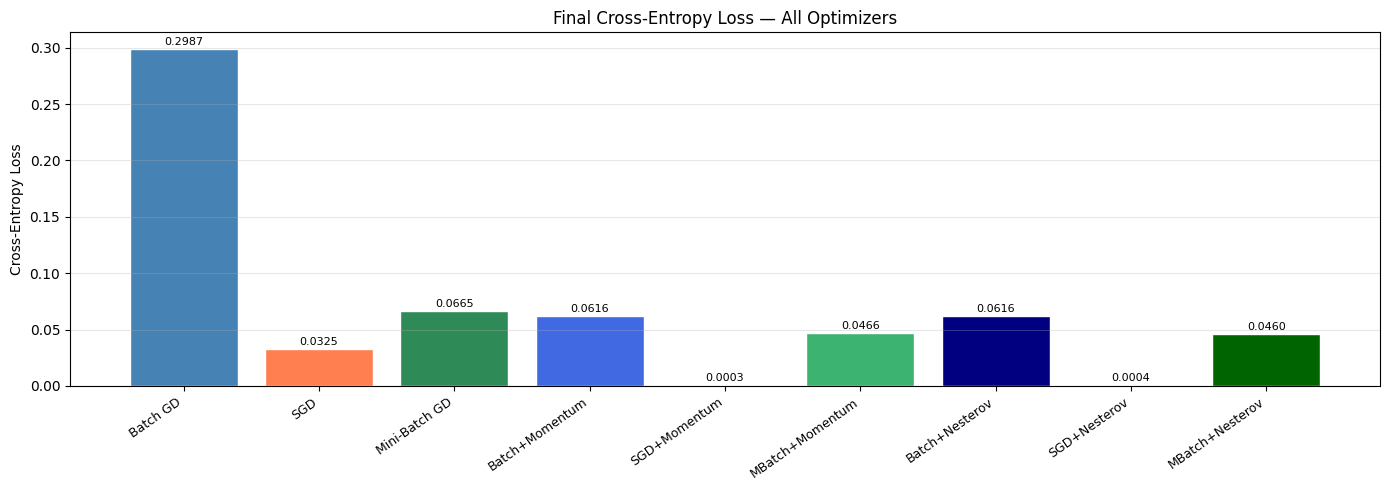


Optimizer                Final Loss
------------------------------------
  SGD+Momentum               0.0003
  SGD+Nesterov               0.0004
  SGD                        0.0325
  MBatch+Nesterov            0.0460
  MBatch+Momentum            0.0466
  Batch+Momentum             0.0616
  Batch+Nesterov             0.0616
  Mini-Batch GD              0.0665
  Batch GD                   0.2987

 Best Optimizer : SGD+Momentum  |  Final Loss: 0.0003


In [26]:
# ─────────────────────────────────────────────────────────────
# STEP 17 : Full Optimizer Comparison
# ─────────────────────────────────────────────────────────────

all_results = {
    'Batch GD'        : loss_batch,
    'SGD'             : loss_sgd,
    'Mini-Batch GD'   : loss_mb,
    'Batch+Momentum'  : loss_mom_batch,
    'SGD+Momentum'    : loss_mom_sgd,
    'MBatch+Momentum' : loss_mom_mb,
    'Batch+Nesterov'  : loss_nag_batch,
    'SGD+Nesterov'    : loss_nag_sgd,
    'MBatch+Nesterov' : loss_nag_mb,
}

palette9 = ['steelblue','coral','seagreen',
            'royalblue','tomato','mediumseagreen',
            'navy','firebrick','darkgreen']
styles9   = ['-','-','-','--','--','--',':',':',':']

fig, ax = plt.subplots(figsize=(14, 6))
for (name, lh), c, s in zip(all_results.items(), palette9, styles9):
    ax.plot(lh, label=name, color=c, linestyle=s, linewidth=1.8)
ax.set_title('All Optimizer Comparison — Cross-Entropy Loss vs Epoch', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(ncol=3, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Bar Chart — Final Loss
names_list   = list(all_results.keys())
final_losses = [lh[-1] for lh in all_results.values()]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names_list, final_losses, color=palette9, edgecolor='white')
for bar, val in zip(bars, final_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Final Cross-Entropy Loss — All Optimizers')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_xticks(range(len(names_list)))
ax.set_xticklabels(names_list, rotation=35, ha='right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# Summary Table
print(f"\n{'Optimizer':<22} {'Final Loss':>12}")
print("-" * 36)
sorted_res = sorted(all_results.items(), key=lambda x: x[1][-1])
for name, lh in sorted_res:
    print(f"  {name:<20} {lh[-1]:>12.4f}")
best = sorted_res[0]
print(f"\n Best Optimizer : {best[0]}  |  Final Loss: {best[1][-1]:.4f}")


Retraining best model (Mini-Batch + Momentum) for 1000 epochs...

 MODEL EVALUATION RESULTS
  Train Loss     : 0.0320
  Test  Loss     : 0.0879
  Train Accuracy : 99.17%
  Test  Accuracy : 96.67%


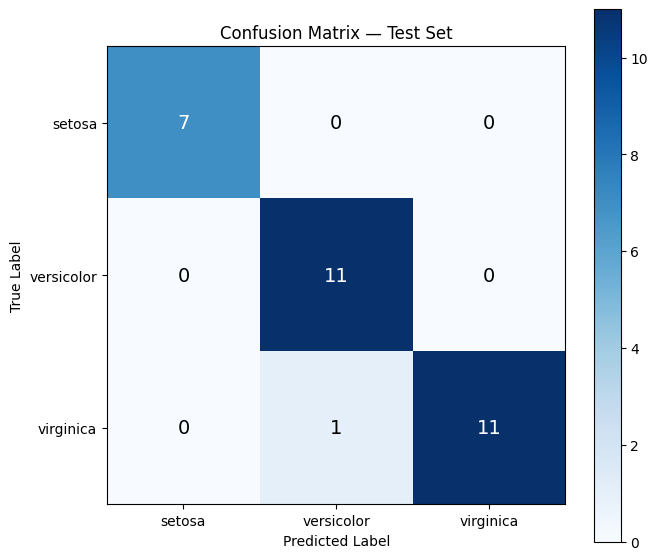


Predicted Probabilities — First 15 Test Samples
----------------------------------------------------------------------
#    True Class           Setosa   Versicolor  Virginica    Predicted
----------------------------------------------------------------------
1    versicolor           0.0000       0.9987     0.0013  versicolor ✓
2    setosa               0.9918       0.0082     0.0000  setosa ✓
3    versicolor           0.0000       1.0000     0.0000  versicolor ✓
4    versicolor           0.0000       0.9753     0.0247  versicolor ✓
5    setosa               0.9996       0.0004     0.0000  setosa ✓
6    versicolor           0.0030       0.9970     0.0000  versicolor ✓
7    virginica            0.0000       0.0004     0.9996  virginica ✓
8    virginica            0.0000       0.0002     0.9998  virginica ✓
9    setosa               0.9996       0.0004     0.0000  setosa ✓
10   versicolor           0.0005       0.9995     0.0000  versicolor ✓
11   virginica            0.0000       0.00

In [27]:
# ─────────────────────────────────────────────────────────────
# STEP 18 : Evaluation on Test Set
# ─────────────────────────────────────────────────────────────

def accuracy(y_true, y_pred):
    """Compare argmax of one-hot true vs predicted probabilities."""
    true_labels = np.argmax(y_true,  axis=1)
    pred_labels = np.argmax(y_pred,  axis=1)
    return np.mean(true_labels == pred_labels)

def confusion_matrix_manual(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    tl = np.argmax(y_true, axis=1)
    pl = np.argmax(y_pred, axis=1)
    for t, p in zip(tl, pl):
        cm[t][p] += 1
    return cm

print("Retraining best model (Mini-Batch + Momentum) for 1000 epochs...")
W1_best, b1_best, W2_best, b2_best, loss_best = train_momentum(
    X_train_scaled, y_train,
    hidden_size=8, lr=0.1, epochs=1000,
    beta=0.9, batch_type='minibatch', batch_size=16, seed=42
)

_, _, _, y_train_pred = forward_propagation(X_train_scaled, W1_best, b1_best, W2_best, b2_best)
_, _, _, y_test_pred  = forward_propagation(X_test_scaled,  W1_best, b1_best, W2_best, b2_best)

train_loss = compute_cross_entropy(y_train, y_train_pred)
test_loss  = compute_cross_entropy(y_test,  y_test_pred)
train_acc  = accuracy(y_train, y_train_pred)
test_acc   = accuracy(y_test,  y_test_pred)

print("\n" + "="*50)
print(" MODEL EVALUATION RESULTS")
print("="*50)
print(f"  Train Loss     : {train_loss:.4f}")
print(f"  Test  Loss     : {test_loss:.4f}")
print(f"  Train Accuracy : {train_acc*100:.2f}%")
print(f"  Test  Accuracy : {test_acc*100:.2f}%")
print("="*50)

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix_manual(y_test, y_test_pred, num_classes=3)
short_names = [c.replace('Iris-','') for c in class_names]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(short_names); ax.set_yticklabels(short_names)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Test Set')
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

# ── Predicted Probabilities for First 15 Test Samples ────────
print("\nPredicted Probabilities — First 15 Test Samples")
print("-" * 70)
print(f"{'#':<4} {'True Class':<18} {'Setosa':>8} {'Versicolor':>12} {'Virginica':>10} {'Predicted':>12}")
print("-" * 70)
true_idxs = np.argmax(y_test,      axis=1)
pred_idxs = np.argmax(y_test_pred, axis=1)
for i in range(min(15, len(y_test))):
    tc = class_names[true_idxs[i]].replace('Iris-','')
    pc = class_names[pred_idxs[i]].replace('Iris-','')
    p  = y_test_pred[i]
    match = "✓" if true_idxs[i] == pred_idxs[i] else "✗"
    print(f"{i+1:<4} {tc:<18} {p[0]:>8.4f} {p[1]:>12.4f} {p[2]:>10.4f}  {pc} {match}")

# ── Per-Class Accuracy ────────────────────────────────────────
print("\nPer-Class Accuracy:")
for i, cname in enumerate(class_names):
    mask        = (true_idxs == i)
    class_acc   = np.mean(pred_idxs[mask] == i) if mask.sum() > 0 else 0.0
    print(f"  {cname:<22}: {class_acc*100:.2f}%  ({mask.sum()} samples)")


In [28]:
# ─────────────────────────────────────────────────────────────
# SUMMARY & DISCUSSION
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"""
   Dataset:
   Iris Dataset
   150 samples, 4 input features, 3 classes

 Neural Network Architecture:
   Input Layer  → 4 neurons
                  (SepalLength, SepalWidth, PetalLength, PetalWidth)
   Hidden Layer → 8 neurons (Sigmoid activation)
   Output Layer → 3 neurons (Softmax — multi-class classification)

 Training Details:
   Loss Function  : Cross-Entropy
   Normalization  : Z-score standardization
   Train/Test     : 80% / 20% split (120 / 30 samples)

 Optimizers Implemented:
   Batch Gradient Descent
   Stochastic Gradient Descent (SGD)
   Mini-Batch Gradient Descent
   Momentum (Batch / SGD / Mini-Batch)
   Nesterov Accelerated Gradient (Batch / SGD / Mini-Batch)

 Experiments Conducted:
   Learning Rate Comparison   (0.001, 0.01, 0.1)
   Hidden Layer Size Comparison (2, 4, 8, 16 neurons)
   Optimizer Performance Comparison (9 variants)

 Key Findings:
   - Higher learning rate (0.1) achieves faster convergence
   - Iris is linearly separable for Setosa; Versicolor and
     Virginica need more capacity to distinguish
   - Mini-Batch + Momentum offers the best balance of
     speed, smoothness, and generalization
   - Nesterov gives slightly smoother convergence than standard Momentum
   - SGD is noisier but generalizes well on small datasets
""")
print("=" * 65)
print(f" Best Test Loss     : {test_loss:.4f}")
print(f" Best Test Accuracy : {test_acc*100:.2f}%")
print("=" * 65)

SUMMARY

   Dataset:
   Iris Dataset
   150 samples, 4 input features, 3 classes
 
 Neural Network Architecture:
   Input Layer  → 4 neurons
                  (SepalLength, SepalWidth, PetalLength, PetalWidth)
   Hidden Layer → 8 neurons (Sigmoid activation)
   Output Layer → 3 neurons (Softmax — multi-class classification)
 
 Training Details:
   Loss Function  : Cross-Entropy
   Normalization  : Z-score standardization
   Train/Test     : 80% / 20% split (120 / 30 samples)
 
 Optimizers Implemented:
   Batch Gradient Descent
   Stochastic Gradient Descent (SGD)
   Mini-Batch Gradient Descent
   Momentum (Batch / SGD / Mini-Batch)
   Nesterov Accelerated Gradient (Batch / SGD / Mini-Batch)
 
 Experiments Conducted:
   Learning Rate Comparison   (0.001, 0.01, 0.1)
   Hidden Layer Size Comparison (2, 4, 8, 16 neurons)
   Optimizer Performance Comparison (9 variants)
 
 Key Findings:
   - Higher learning rate (0.1) achieves faster convergence
   - Iris is linearly separable for Setosa; V